GRU Foundations

Goal:
- understand recurrence and hidden state
- learn GRU tensor shapes
- build GRU models for sequence tasks
- visualize hidden-state behavior


In [1]:
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
random.seed(42)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


In [2]:
x = torch.randn(4, 6, 3)

print("shape:", x.shape)
print("batch size:", x.shape[0])
print("sequence length:", x.shape[1])
print("input size:", x.shape[2])

shape: torch.Size([4, 6, 3])
batch size: 4
sequence length: 6
input size: 3


Why recurrence?

A feedforward network sees all inputs at once,
but it does not naturally maintain a running memory over time.

A recurrent model updates a hidden state:
h_t = f(x_t, h_{t-1})

That means:
current state depends on
- current input
- previous memory

GRU in PyTorch

We can create a GRU with:
nn.GRU(input_size, hidden_size, batch_first=True)

In [3]:
gru = nn.GRU(input_size=3, hidden_size=5, batch_first=True)
print(gru)

GRU(3, 5, batch_first=True)


What does a GRU return?

A GRU returns:
- output: hidden states for all time steps
- h_n: final hidden state

Shapes with batch_first=True:

output shape = (B, T, hidden_size)

h_n shape = (num_layers, B, hidden_size)

In [4]:
x = torch.randn(4, 6, 3)

output, h_n = gru(x)

print("input shape:", x.shape)
print("output shape:", output.shape)
print("final hidden shape:", h_n.shape)

input shape: torch.Size([4, 6, 3])
output shape: torch.Size([4, 6, 5])
final hidden shape: torch.Size([1, 4, 5])


In [5]:
print("last time-step output shape:", output[:, -1, :].shape)
print("h_n[0] shape:", h_n[0].shape)

last time-step output shape: torch.Size([4, 5])
h_n[0] shape: torch.Size([4, 5])


In [6]:
difference = torch.abs(output[:, -1, :] - h_n[0]).max()
print("max difference:", difference.item())

max difference: 0.0


Multi-layer GRU

If num_layers > 1,
the hidden state shape changes.

In [7]:
gru_multi = nn.GRU(input_size=3, hidden_size=5, num_layers=2, batch_first=True)

x = torch.randn(4, 6, 3)
output, h_n = gru_multi(x)

print("output shape:", output.shape)
print("h_n shape:", h_n.shape)

output shape: torch.Size([4, 6, 5])
h_n shape: torch.Size([2, 4, 5])


Meaning of h_n for multi-layer GRU

If num_layers = 2:
h_n[0] = final hidden state of layer 1
h_n[1] = final hidden state of layer 2

Usually, for final prediction,
we use the top layer final hidden state.

In [8]:
print(h_n[0].shape)
print(h_n[1].shape)

torch.Size([4, 5])
torch.Size([4, 5])


Build synthetic sequence data

Task:
Given a binary sequence,
predict whether it contains more 1s than 0s.

This is a simple sequence classification task.

In [9]:
def generate_binary_sequence_data(num_samples=1000, seq_len=10):
    X = []
    y = []

    for _ in range(num_samples):
        seq = torch.randint(0, 2, (seq_len,)).float()
        label = 1 if seq.sum() > (seq_len / 2) else 0

        X.append(seq.unsqueeze(-1))   # shape becomes (seq_len, 1)
        y.append(label)

    X = torch.stack(X)                # shape: (num_samples, seq_len, 1)
    y = torch.tensor(y, dtype=torch.long)

    return X, y

In [10]:
X, y = generate_binary_sequence_data(num_samples=8, seq_len=10)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X[0].squeeze(-1))
print(y[0])

X shape: torch.Size([8, 10, 1])
y shape: torch.Size([8])
tensor([0., 1., 0., 0., 0., 1., 1., 0., 1., 1.])
tensor(0)


Train / validation split
Production habit:
separate train and validation data.

In [11]:
X_all, y_all = generate_binary_sequence_data(num_samples=2000, seq_len=10)

X_train = X_all[:1600]
y_train = y_all[:1600]

X_val = X_all[1600:]
y_val = y_all[1600:]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([1600, 10, 1]) torch.Size([1600])
torch.Size([400, 10, 1]) torch.Size([400])


Batch helper

In [12]:
def get_batch(X, y, batch_size=32):
    indices = torch.randint(0, X.shape[0], (batch_size,))
    xb = X[indices]
    yb = y[indices]
    return xb, yb

In [13]:
xb, yb = get_batch(X_train, y_train, batch_size=4)
print(xb.shape, yb.shape)

torch.Size([4, 10, 1]) torch.Size([4])


GRU classifier

We will:
- run the sequence through a GRU
- take the final hidden state
- use a linear layer for classification

In [14]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, num_classes=2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (B, T, input_size)

        output, h_n = self.gru(x)

        # h_n shape: (num_layers, B, hidden_size)
        # take final hidden state from top GRU layer
        final_hidden = h_n[-1]

        logits = self.classifier(final_hidden)

        return logits, output, h_n

In [15]:
model = GRUClassifier(input_size=1, hidden_size=16, num_layers=1, num_classes=2).to(device)
print(model)

GRUClassifier(
  (gru): GRU(1, 16, batch_first=True)
  (classifier): Linear(in_features=16, out_features=2, bias=True)
)


In [16]:
xb, yb = get_batch(X_train, y_train, batch_size=4)
xb = xb.to(device)

logits, output, h_n = model(xb)

print("input shape:", xb.shape)
print("logits shape:", logits.shape)
print("output shape:", output.shape)
print("h_n shape:", h_n.shape)

input shape: torch.Size([4, 10, 1])
logits shape: torch.Size([4, 2])
output shape: torch.Size([4, 10, 16])
h_n shape: torch.Size([1, 4, 16])


In [18]:
#  Classification loss
criterion = nn.CrossEntropyLoss()

yb = yb.to(device)
loss = criterion(logits, yb)

print("loss:", loss.item())

loss: 0.6797192692756653


In [20]:
def evaluate_classifier(model, X, y, batch_size=64, num_batches=20):
    model.eval()

    losses = []
    accs = []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for _ in range(num_batches):
            xb, yb = get_batch(X, y, batch_size=batch_size)
            xb = xb.to(device)
            yb = yb.to(device)

            logits, _, _ = model(xb)
            loss = criterion(logits, yb)

            preds = torch.argmax(logits, dim=1)
            acc = (preds == yb).float().mean().item()

            losses.append(loss.item())
            accs.append(acc)

    model.train()
    return sum(losses) / len(losses), sum(accs) / len(accs)

In [21]:
model = GRUClassifier(input_size=1, hidden_size=32, num_layers=1, num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

num_steps = 400

for step in range(num_steps):
    xb, yb = get_batch(X_train, y_train, batch_size=64)
    xb = xb.to(device)
    yb = yb.to(device)

    logits, output, h_n = model(xb)
    loss = criterion(logits, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        train_loss, train_acc = evaluate_classifier(model, X_train, y_train)
        val_loss, val_acc = evaluate_classifier(model, X_val, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(
            f"Step {step:03d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

Step 000 | Train Loss: 0.6619 | Train Acc: 0.6594 | Val Loss: 0.6786 | Val Acc: 0.5906
Step 020 | Train Loss: 0.6551 | Train Acc: 0.6133 | Val Loss: 0.6476 | Val Acc: 0.6336
Step 040 | Train Loss: 0.6216 | Train Acc: 0.6289 | Val Loss: 0.6326 | Val Acc: 0.6125
Step 060 | Train Loss: 0.5478 | Train Acc: 0.6648 | Val Loss: 0.5509 | Val Acc: 0.6766
Step 080 | Train Loss: 0.3246 | Train Acc: 0.8734 | Val Loss: 0.2976 | Val Acc: 0.8836
Step 100 | Train Loss: 0.2787 | Train Acc: 0.9203 | Val Loss: 0.2616 | Val Acc: 0.9375
Step 120 | Train Loss: 0.2417 | Train Acc: 0.9070 | Val Loss: 0.2174 | Val Acc: 0.9195
Step 140 | Train Loss: 0.2126 | Train Acc: 0.9242 | Val Loss: 0.1954 | Val Acc: 0.9328
Step 160 | Train Loss: 0.1946 | Train Acc: 0.9242 | Val Loss: 0.1959 | Val Acc: 0.9156
Step 180 | Train Loss: 0.1564 | Train Acc: 0.9766 | Val Loss: 0.1456 | Val Acc: 0.9648
Step 200 | Train Loss: 0.1563 | Train Acc: 0.9164 | Val Loss: 0.1397 | Val Acc: 0.9461
Step 220 | Train Loss: 0.1251 | Train Acc: 

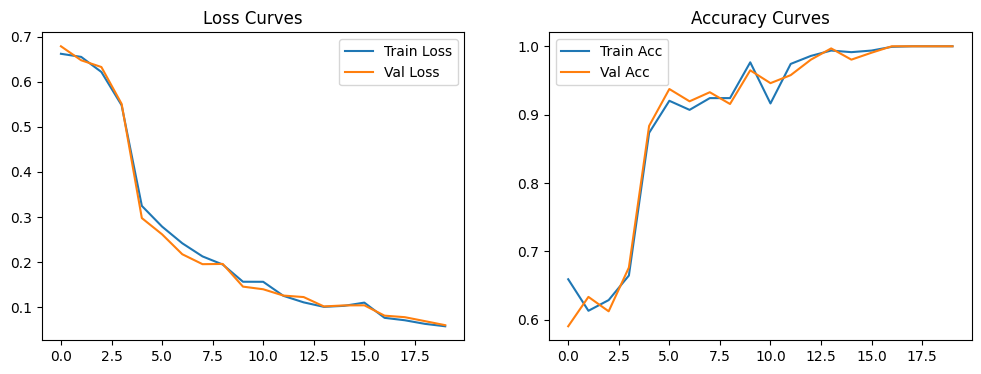

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="Train Acc")
plt.plot(val_acc_history, label="Val Acc")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [23]:
model.eval()

xb, yb = get_batch(X_val, y_val, batch_size=8)
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits, output, h_n = model(xb)
    preds = torch.argmax(logits, dim=1)

print("sequences:")
print(xb.squeeze(-1).cpu())

print("\nlabels:")
print(yb.cpu())

print("\npredictions:")
print(preds.cpu())

sequences:
tensor([[0., 1., 0., 0., 0., 1., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 1., 1., 0., 0., 1., 1., 1., 0., 1.],
        [1., 0., 0., 1., 0., 1., 0., 0., 0., 1.],
        [1., 0., 0., 0., 1., 0., 1., 1., 1., 1.],
        [1., 1., 0., 1., 1., 0., 0., 1., 0., 1.],
        [0., 0., 0., 0., 1., 1., 0., 1., 0., 0.],
        [1., 0., 0., 1., 1., 1., 1., 0., 0., 1.]])

labels:
tensor([0, 0, 1, 0, 1, 1, 0, 1])

predictions:
tensor([0, 0, 1, 0, 1, 1, 0, 1])


Visualize hidden states over time

This is very important intuition.

The GRU hidden state changes at every time step.
We can visualize how one hidden dimension evolves across time.
```

In [24]:
example_seq = xb[0:1]

with torch.no_grad():
    logits, output, h_n = model(example_seq)

hidden_over_time = output[0].cpu()   # shape: (T, hidden_size)

print(hidden_over_time.shape)

torch.Size([10, 32])


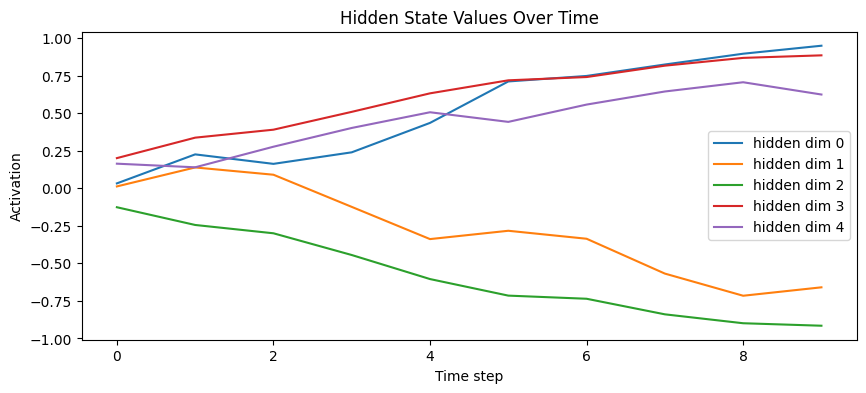

In [25]:
plt.figure(figsize=(10, 4))

for dim in range(min(5, hidden_over_time.shape[1])):
    plt.plot(hidden_over_time[:, dim].numpy(), label=f"hidden dim {dim}")

plt.legend()
plt.title("Hidden State Values Over Time")
plt.xlabel("Time step")
plt.ylabel("Activation")
plt.show()

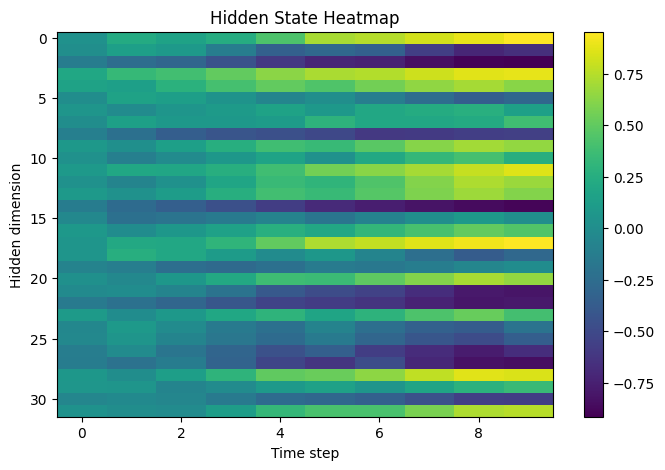

In [26]:
plt.figure(figsize=(8, 5))
plt.imshow(hidden_over_time.numpy().T, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("Hidden State Heatmap")
plt.xlabel("Time step")
plt.ylabel("Hidden dimension")
plt.show()